<a href="https://colab.research.google.com/github/sangeetha2004s/Medicinal-Plant-Classification/blob/main/Medicinal_Plants_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing libraries

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
#Install kaggle API client
!pip install -q kaggle

In [ ]:
!mkdir  ~/.kaggle
!cp kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists
cp: cannot stat 'kaggle.json': No such file or directory


In [ ]:
mv kaggle.json /root/.kaggle/


mv: cannot stat 'kaggle.json': No such file or directory


In [ ]:
#to set permissions
!chmod 600 /root/.kaggle/kaggle.json


chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
#list all available datasets
!kaggle datasets list

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 5, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.11/dist-packages/kaggle/__init__.py", line 7, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 407, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


# Downloading dataset

In [ ]:
!kaggle datasets download -d aryashah2k/indian-medicinal-leaves-dataset

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/indian-medicinal-leaves-dataset
License(s): CC-BY-NC-SA-4.0
... resuming from 1635778560 bytes (8027672932 bytes left) ...
100% 8.99G/9.00G [01:07<00:00, 201MB/s]
100% 9.00G/9.00G [01:07<00:00, 119MB/s]


In [ ]:
!unzip \*.zip && rm *.zip

Streaming output truncated to the last 5000 lines.
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5611.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5612.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5613.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5614.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5615.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5616.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5617.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5618.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5619.jpg  
  inflating: Indian Medicinal Leaves Image Datasets/Medicinal plant dataset/Avacado/5620.jpg  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_hub as hub
import tensorflow_datasets as tfds
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import tensorflow_hub as hub
import tensorflow_datasets as tfds
from tensorflow.keras import layers

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow import keras
import cv2
import os
import numpy as np

In [ ]:
dataset_path= 'Indian Medicinal Leaves Image Datasets/Medicinal Leaf dataset'

In [ ]:
class_names = sorted(os.listdir(dataset_path))

# Print the class names
print(class_names)

['Aloevera', 'Amla', 'Amruthaballi', 'Arali', 'Astma_weed', 'Badipala', 'Balloon_Vine', 'Bamboo', 'Beans', 'Betel', 'Bhrami', 'Bringaraja', 'Caricature', 'Castor', 'Catharanthus', 'Chakte', 'Chilly', 'Citron lime (herelikai)', 'Coffee', 'Common rue(naagdalli)', 'Coriender', 'Curry', 'Doddpathre', 'Drumstick', 'Ekka', 'Eucalyptus', 'Ganigale', 'Ganike', 'Gasagase', 'Ginger', 'Globe Amarnath', 'Guava', 'Henna', 'Hibiscus', 'Honge', 'Insulin', 'Jackfruit', 'Jasmine', 'Kambajala', 'Kasambruga', 'Kohlrabi', 'Lantana', 'Lemon', 'Lemongrass', 'Malabar_Nut', 'Malabar_Spinach', 'Mango', 'Marigold', 'Mint', 'Neem', 'Nelavembu', 'Nerale', 'Nooni', 'Onion', 'Padri', 'Palak(Spinach)', 'Papaya', 'Parijatha', 'Pea', 'Pepper', 'Pomoegranate', 'Pumpkin', 'Raddish', 'Rose', 'Sampige', 'Sapota', 'Seethaashoka', 'Seethapala', 'Spinach1', 'Tamarind', 'Taro', 'Tecoma', 'Thumbe', 'Tomato', 'Tulsi', 'Turmeric', 'ashoka', 'camphor', 'kamakasturi', 'kepala']


In [ ]:
def load_and_preprocess_images(dataset_path, image_size=(128, 128)):
    images = []
    labels = []

    # Iterate through class directories
    for class_dir in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_dir)
        class_label = int(class_dir)  # Convert directory name to label if needed

        # Iterate through images in the class directory
        for image_file in os.listdir(class_path):
            image_path = os.path.join(class_path, image_file)

            # Read and preprocess the image
            image = cv2.imread(image_path)
            image = cv2.resize(image, image_size)
            image = image.astype(np.float32) / 255.0  # Normalize pixel values
            # Append the image and label to lists
            images.append(image)
            labels.append(class_label)

    return np.array(images), np.array(labels)


# **Transfer Learning with MobileNet Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Constants
IMAGE_RES = 224
BATCH_SIZE = 32
# Load the dataset
data = tf.keras.utils.image_dataset_from_directory(
    'Indian Medicinal Leaves Image Datasets/Medicinal Leaf dataset',
    image_size=(IMAGE_RES, IMAGE_RES),
    batch_size=BATCH_SIZE,
    validation_split=0.2,  # 20% of the data will be used for testing
    subset="training",     # Specify "training" to get the training subset
    seed=42,
    label_mode='int'
)
num_examples = data.cardinality().numpy()
num_classes = len(data.class_names)

# Split the data into training and testing
testing_data = tf.keras.utils.image_dataset_from_directory(
    'Indian Medicinal Leaves Image Datasets/Medicinal Leaf dataset',
    image_size=(IMAGE_RES, IMAGE_RES),
    batch_size=BATCH_SIZE,
    validation_split=0.2,  # No validation split for testing
    seed=42,
    label_mode='int',
    subset="validation"    # Specify "validation" to get the testing subset
)

Found 6900 files belonging to 80 classes.
Using 5520 files for training.
Found 6900 files belonging to 80 classes.
Using 1380 files for validation.


In [ ]:
# Constants
IMAGE_RES = 224  # InceptionV3 input shape
BATCH_SIZE = 32

# Training Model

In [ ]:
def format_image(image, label):
    image = tf.image.resize(image, (IMAGE_RES, IMAGE_RES)) / 255.0
    return image, label
train_data = data
validation_split = 0.2
num_validation_samples = int(num_examples * validation_split)
validation_data = data.take(num_validation_samples)

train_batches = train_data.map(format_image).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_batches = validation_data.map(format_image).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_RES, IMAGE_RES, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')

model = tf.keras.Sequential([
    base_model,
    global_average_layer,
    prediction_layer
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_batches, validation_data=validation_batches, epochs=10)

model.save('medicinal_leaf_model.h5')

# Evaluate the model on the testing dataset
testing_batches = testing_data.map(format_image).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_loss, test_accuracy = model.evaluate(testing_batches)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 646s 4s/step - accuracy: 0.2781 - loss: 3.3156 - val_accuracy: 0.7840 - val_loss: 1.0016
Epoch 2/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.8108 - loss: 0.8800 - val_accuracy: 0.8952 - val_loss: 0.5457
Epoch 3/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.9079 - loss: 0.5037 - val_accuracy: 0.9467 - val_loss: 0.3491
Epoch 4/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 425s 2s/step - accuracy: 0.9523 - loss: 0.3302 - val_accuracy: 0.9724 - val_loss: 0.2444
Epoch 5/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.9761 - loss: 0.2325 - val_accuracy: 0.9835 - val_loss: 0.1807
Epoch 6/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.9856 - loss: 0.1715 - val_accuracy: 0.9890 - val_loss: 0.1385
Epoch 7/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.9914 - loss: 0.1307 - val_accuracy: 0.9945 - val_loss: 0.1090
Epoch 8/10
173/173 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/

44/44 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.8820 - loss: 0.4272
Test Accuracy: 0.8753623366355896
Test Loss: 0.4457414746284485


# Model's Description

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 80)                  │         102,480 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,565,426 (9.79 MB)

 Trainable params: 102,480 (400.31 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 204,962 (800.64 KB)

# Plot for training and validation

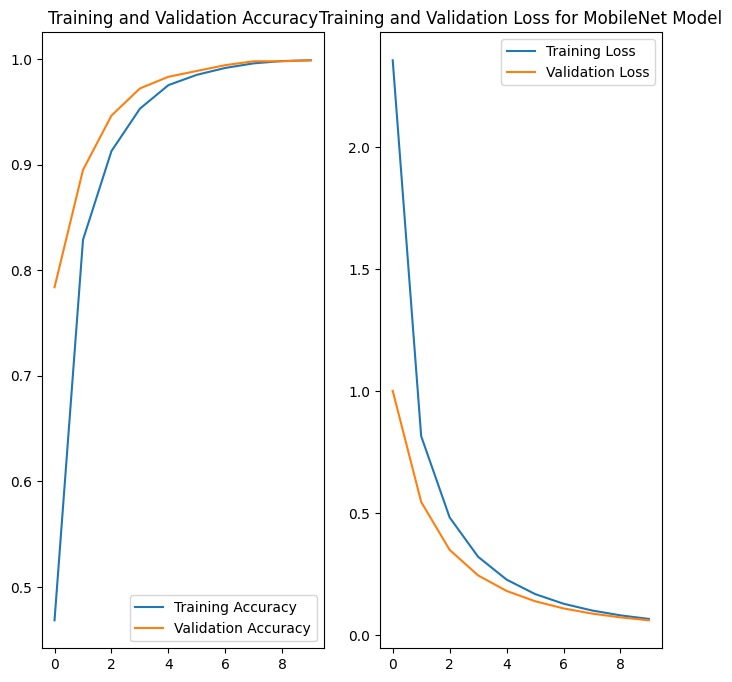

In [ ]:
EPOCHS = 10
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)
epochs_range = range(EPOCHS)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss for MobileNet Model')
plt.show()

In [ ]:
import tensorflow as tf
# Suppress TensorFlow warnings
tf.get_logger().setLevel("ERROR")
# Save the trained model to a file
model.save("Model_Mobilenet.h5")
# Download the saved model file
from google.colab import files
files.download("Model_Mobilenet.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Prediction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


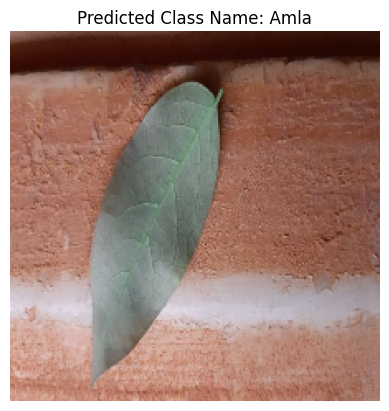

In [ ]:
input_image_path = '/content/amla.jpg'
input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
input_image_array = img_to_array(input_image)
input_image_array = input_image_array / 255.0  # Normalize the image
input_image_array = input_image_array[tf.newaxis, ...]
predictions = model.predict(input_image_array)
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
predicted_class_name = data.class_names[predicted_class_index]
plt.imshow(input_image)
plt.title("Predicted Class Name: " + predicted_class_name)
plt.axis("off")
plt.show()

In [ ]:
input_image_path = '/content/castor.jpg'
input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
input_image_array = img_to_array(input_image)
input_image_array = input_image_array / 255.0  # Normalize the image
input_image_array = input_image_array[tf.newaxis, ...]
predictions = model.predict(input_image_array)
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
predicted_class_name = data.class_names[predicted_class_index]
plt.imshow(input_image)
plt.title("Predicted Class Name: " + predicted_class_name)
plt.axis("off")
plt.show()

In [ ]:
input_image_path = '/content/bamboo.jpg'
input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
input_image_array = img_to_array(input_image)
input_image_array = input_image_array / 255.0  # Normalize the image
input_image_array = input_image_array[tf.newaxis, ...]
predictions = model.predict(input_image_array)
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
predicted_class_name = data.class_names[predicted_class_index]

plt.imshow(input_image)
plt.title("Predicted Class Name: " + predicted_class_name)
plt.axis("off")
plt.show()

In [ ]:
# input_image_path = 'aloevera .jpg'
# input_image = load_img(input_image_path, target_size=(IMAGE_RES, IMAGE_RES))
# input_image_array = img_to_array(input_image)
# input_image_array = input_image_array / 255.0  # Normalize the image
# input_image_array = input_image_array[tf.newaxis, ...]
# predictions = model.predict(input_image_array)
# predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
# predicted_class_name = data.class_names[predicted_class_index]

# plt.imshow(input_image)
# plt.title("Predicted Class Name: " + predicted_class_name)
# plt.axis("off")
# plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'aloevera .jpg'

In [ ]:
! pip install streamlit -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.5 MB/s eta 0:00:00


In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 4s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [ ]:
!ls

 aloevera.jpg   drive					  medicinal_leaf_model.h5   sample_data
 amla.jpg      'Indian Medicinal Leaves Image Datasets'   Model_Mobilenet.h5


In [ ]:
!npm init -y


Wrote to /content/package.json:

{
  "name": "content",
  "version": "1.0.0",
  "main": "index.js",
  "scripts": {
    "test": "echo \"Error: no test specified\" && exit 1"
  },
  "keywords": [],
  "author": "",
  "license": "ISC",
  "description": ""
}



⠙

In [ ]:
!npm install --package-lock-only


⠙⠹
up to date, audited 1 package in 629ms
⠹
found 0 vulnerabilities
⠹

In [ ]:
!npm audit

⠙found 0 vulnerabilities
⠙

In [ ]:
pip install pillow


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.67.128.117


In [ ]:
%%writefile app.py
import tensorflow as tf
import numpy as np
import streamlit as st
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import os

IMAGE_RES = 224
BATCH_SIZE = 32


@st.cache_resource
def load_model():

    model = tf.keras.models.load_model('medicinal_leaf_model.h5')
    return model


@st.cache_resource
def get_class_names(dataset_path):
    class_names = sorted(os.listdir(dataset_path))
    return class_names


dataset_path = 'Indian Medicinal Leaves Image Datasets/Medicinal Leaf dataset'


model = load_model()
class_names = get_class_names(dataset_path)


st.title("Indian Medicinal Leaves Classification")
st.write("Upload an image to predict the medicinal leaf class.")


uploaded_file = st.file_uploader("Upload an image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:

    input_image = load_img(uploaded_file, target_size=(IMAGE_RES, IMAGE_RES))
    input_image_array = img_to_array(input_image)
    input_image_array = input_image_array / 255.0
    input_image_array = input_image_array[tf.newaxis, ...]


    predictions = model.predict(input_image_array)
    predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]
    predicted_class_name = class_names[predicted_class_index]


    st.image(input_image, caption="Uploaded Image", use_column_width=True)
    st.write(f"Predicted Class: {predicted_class_name}")


Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.67.128.117:8501

your url is: https://breezy-snails-move.loca.lt
2025-02-08 11:13:08.061414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739013188.129017   27987 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739013188.151993   27987 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-08 11:13:19.872731: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
1/1 ━━━━━━━━━━━━━━━━━━━